# Thread Testing Technical Report

## Methods

Timing accuracy of the refactored heartbeat LED thread was evaluated using software logging. The heartbeat LED was configured to operate at a nominal frequency of 1 Hz with a 25% duty cycle (250 ms on, 750 ms off). The elapsed time between successive LED toggles was measured using system tick timestamps and converted to nanoseconds. Because the LED toggles at the end of each on or off interval, each logged duration corresponds to either the on time or off time of the heartbeat signal.

Terminal output from the device was saved to a text file and parsed in a Jupyter notebook using pandas. Logged durations were separated into short and long intervals using the median duration as a threshold. The shorter durations correspond to the on time while the longer durations correspond to the off time. Paired on and off durations were then used to compute the total period, frequency, and duty cycle.

Because timestamp measurements are quantized to the system clock tick, timing resolution is limited to one tick. When repeated measurements produced identical values, the 95% confidence interval was therefore estimated as plus or minus half of one system tick in the period domain.

## Results

In [3]:
# import .txt log and read "heart" data
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def read_type(fname, keyword):
    df = pd.read_csv(fname, sep=r"\s+", header=None, usecols=[0,3,7],
                     names=['timestamp','type','toggle duration (ns)'],
                     engine="python")
    df = df[df['type'].astype(str).str.contains(keyword, case=False, na=False)].copy()
    df['toggle duration (ms)'] = df['toggle duration (ns)'] / 1e6
    df['frequency (Hz)'] = 1e9 / (2 * df['toggle duration (ns)'])  # toggle duration = half-period
    return df

log_thread_heart  = read_type('thread_2Hz_HB.txt', 'heart')

In [4]:
# heartbeat: split into ON (short) and OFF (long) intervals for 25% duty cycle
thr = log_thread_heart['toggle duration (ns)'].median()

hb_on  = log_thread_heart[log_thread_heart['toggle duration (ns)'] <= thr].copy()  # ~250 ms
hb_off = log_thread_heart[log_thread_heart['toggle duration (ns)'] >  thr].copy()  # ~750 ms

ton_ms  = hb_on['toggle duration (ms)'].reset_index(drop=True)
toff_ms = hb_off['toggle duration (ms)'].reset_index(drop=True)

n = min(len(ton_ms), len(toff_ms))
ton_ms  = ton_ms.iloc[:n]
toff_ms = toff_ms.iloc[:n]

hb_cycles = pd.DataFrame({
    'TON (ms)': ton_ms,
    'TOFF (ms)': toff_ms
})

hb_cycles['Period (ms)'] = hb_cycles['TON (ms)'] + hb_cycles['TOFF (ms)']
hb_cycles['Frequency (Hz)'] = 1000.0 / hb_cycles['Period (ms)']
hb_cycles['Duty Cycle'] = hb_cycles['TON (ms)'] / hb_cycles['Period (ms)']

hb_cycles.head()

,TON (ms),TOFF (ms),Period (ms),Frequency (Hz),Duty Cycle
0,250.152588,750.122070,1000.274658,0.999725,0.250084
1,250.152588,750.152588,1000.305176,0.999695,0.250076
2,250.152588,750.183105,1000.335693,0.999664,0.250069
3,250.152588,750.213623,1000.366211,0.999634,0.250061
4,250.213623,750.152588,1000.366211,0.999634,0.250122


In [7]:
summary_heart = pd.DataFrame({
    'TON (ms)': hb_cycles['TON (ms)'].describe(),
    'TOFF (ms)': hb_cycles['TOFF (ms)'].describe(),
    'Period (ms)': hb_cycles['Period (ms)'].describe(),
    'Frequency (Hz)': hb_cycles['Frequency (Hz)'].describe(),
    'Duty Cycle': hb_cycles['Duty Cycle'].describe()
})

from IPython.display import display
display(summary_heart)

,TON (ms),TOFF (ms),Period (ms),Frequency (Hz),Duty Cycle
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,250.156860,750.157471,1000.314331,0.999686,0.250078
std,0.015651,0.025559,0.029259,0.000029,0.000014
min,250.152587,750.122070,1000.274658,0.999634,0.250061
25%,250.152588,750.152587,1000.305175,0.999664,0.250069
50%,250.152588,750.152588,1000.305176,0.999695,0.250076
75%,250.152588,750.183105,1000.335693,0.999695,0.250084
max,250.213624,750.213623,1000.366211,0.999725,0.250122


### 95% Confidence Interval for Heartbeat LED

In [8]:
# 95% CI
ticks_per_sec = 1e3
tick_s = 1 / ticks_per_sec
half_tick_ms = (tick_s / 2) * 1000

def resolution_ci_ms(mean_ms, decimals=3):
    return (round(mean_ms - half_tick_ms, decimals),
            round(mean_ms + half_tick_ms, decimals))

ci_table = pd.DataFrame({
    "Nominal": [250.0, 750.0, 1000.0, 1.0, 0.25],
    "Measured mean": [
        hb_cycles["TON (ms)"].mean(),
        hb_cycles["TOFF (ms)"].mean(),
        hb_cycles["Period (ms)"].mean(),
        hb_cycles["Frequency (Hz)"].mean(),
        hb_cycles["Duty Cycle"].mean()
    ],
    "95% CI": [
        resolution_ci_ms(hb_cycles["TON (ms)"].mean()),
        resolution_ci_ms(hb_cycles["TOFF (ms)"].mean()),
        resolution_ci_ms(hb_cycles["Period (ms)"].mean()),
        (
            round(1000.0 / (hb_cycles["Period (ms)"].mean() + half_tick_ms), 4),
            round(1000.0 / (hb_cycles["Period (ms)"].mean() - half_tick_ms), 4),
        ),
        (
            round((hb_cycles["TON (ms)"].mean() - half_tick_ms) / (hb_cycles["Period (ms)"].mean() + half_tick_ms), 4),
            round((hb_cycles["TON (ms)"].mean() + half_tick_ms) / (hb_cycles["Period (ms)"].mean() - half_tick_ms), 4),
        )
    ]
}, index=["TON (ms)", "TOFF (ms)", "Period (ms)", "Frequency (Hz)", "Duty Cycle"])

ci_table["Error vs nominal"] = ci_table["Measured mean"] - ci_table["Nominal"]

display(ci_table)

,Nominal,Measured mean,95% CI,Error vs nominal
TON (ms),250.00,250.156860,"(249.657, 250.657)",0.156860
TOFF (ms),750.00,750.157471,"(749.657, 750.657)",0.157471
Period (ms),1000.00,1000.314331,"(999.814, 1000.814)",0.314331
Frequency (Hz),1.00,0.999686,"(0.9992, 1.0002)",-0.000314
Duty Cycle,0.25,0.250078,"(0.2495, 0.2507)",0.000078


## Oscilloscope Measurements

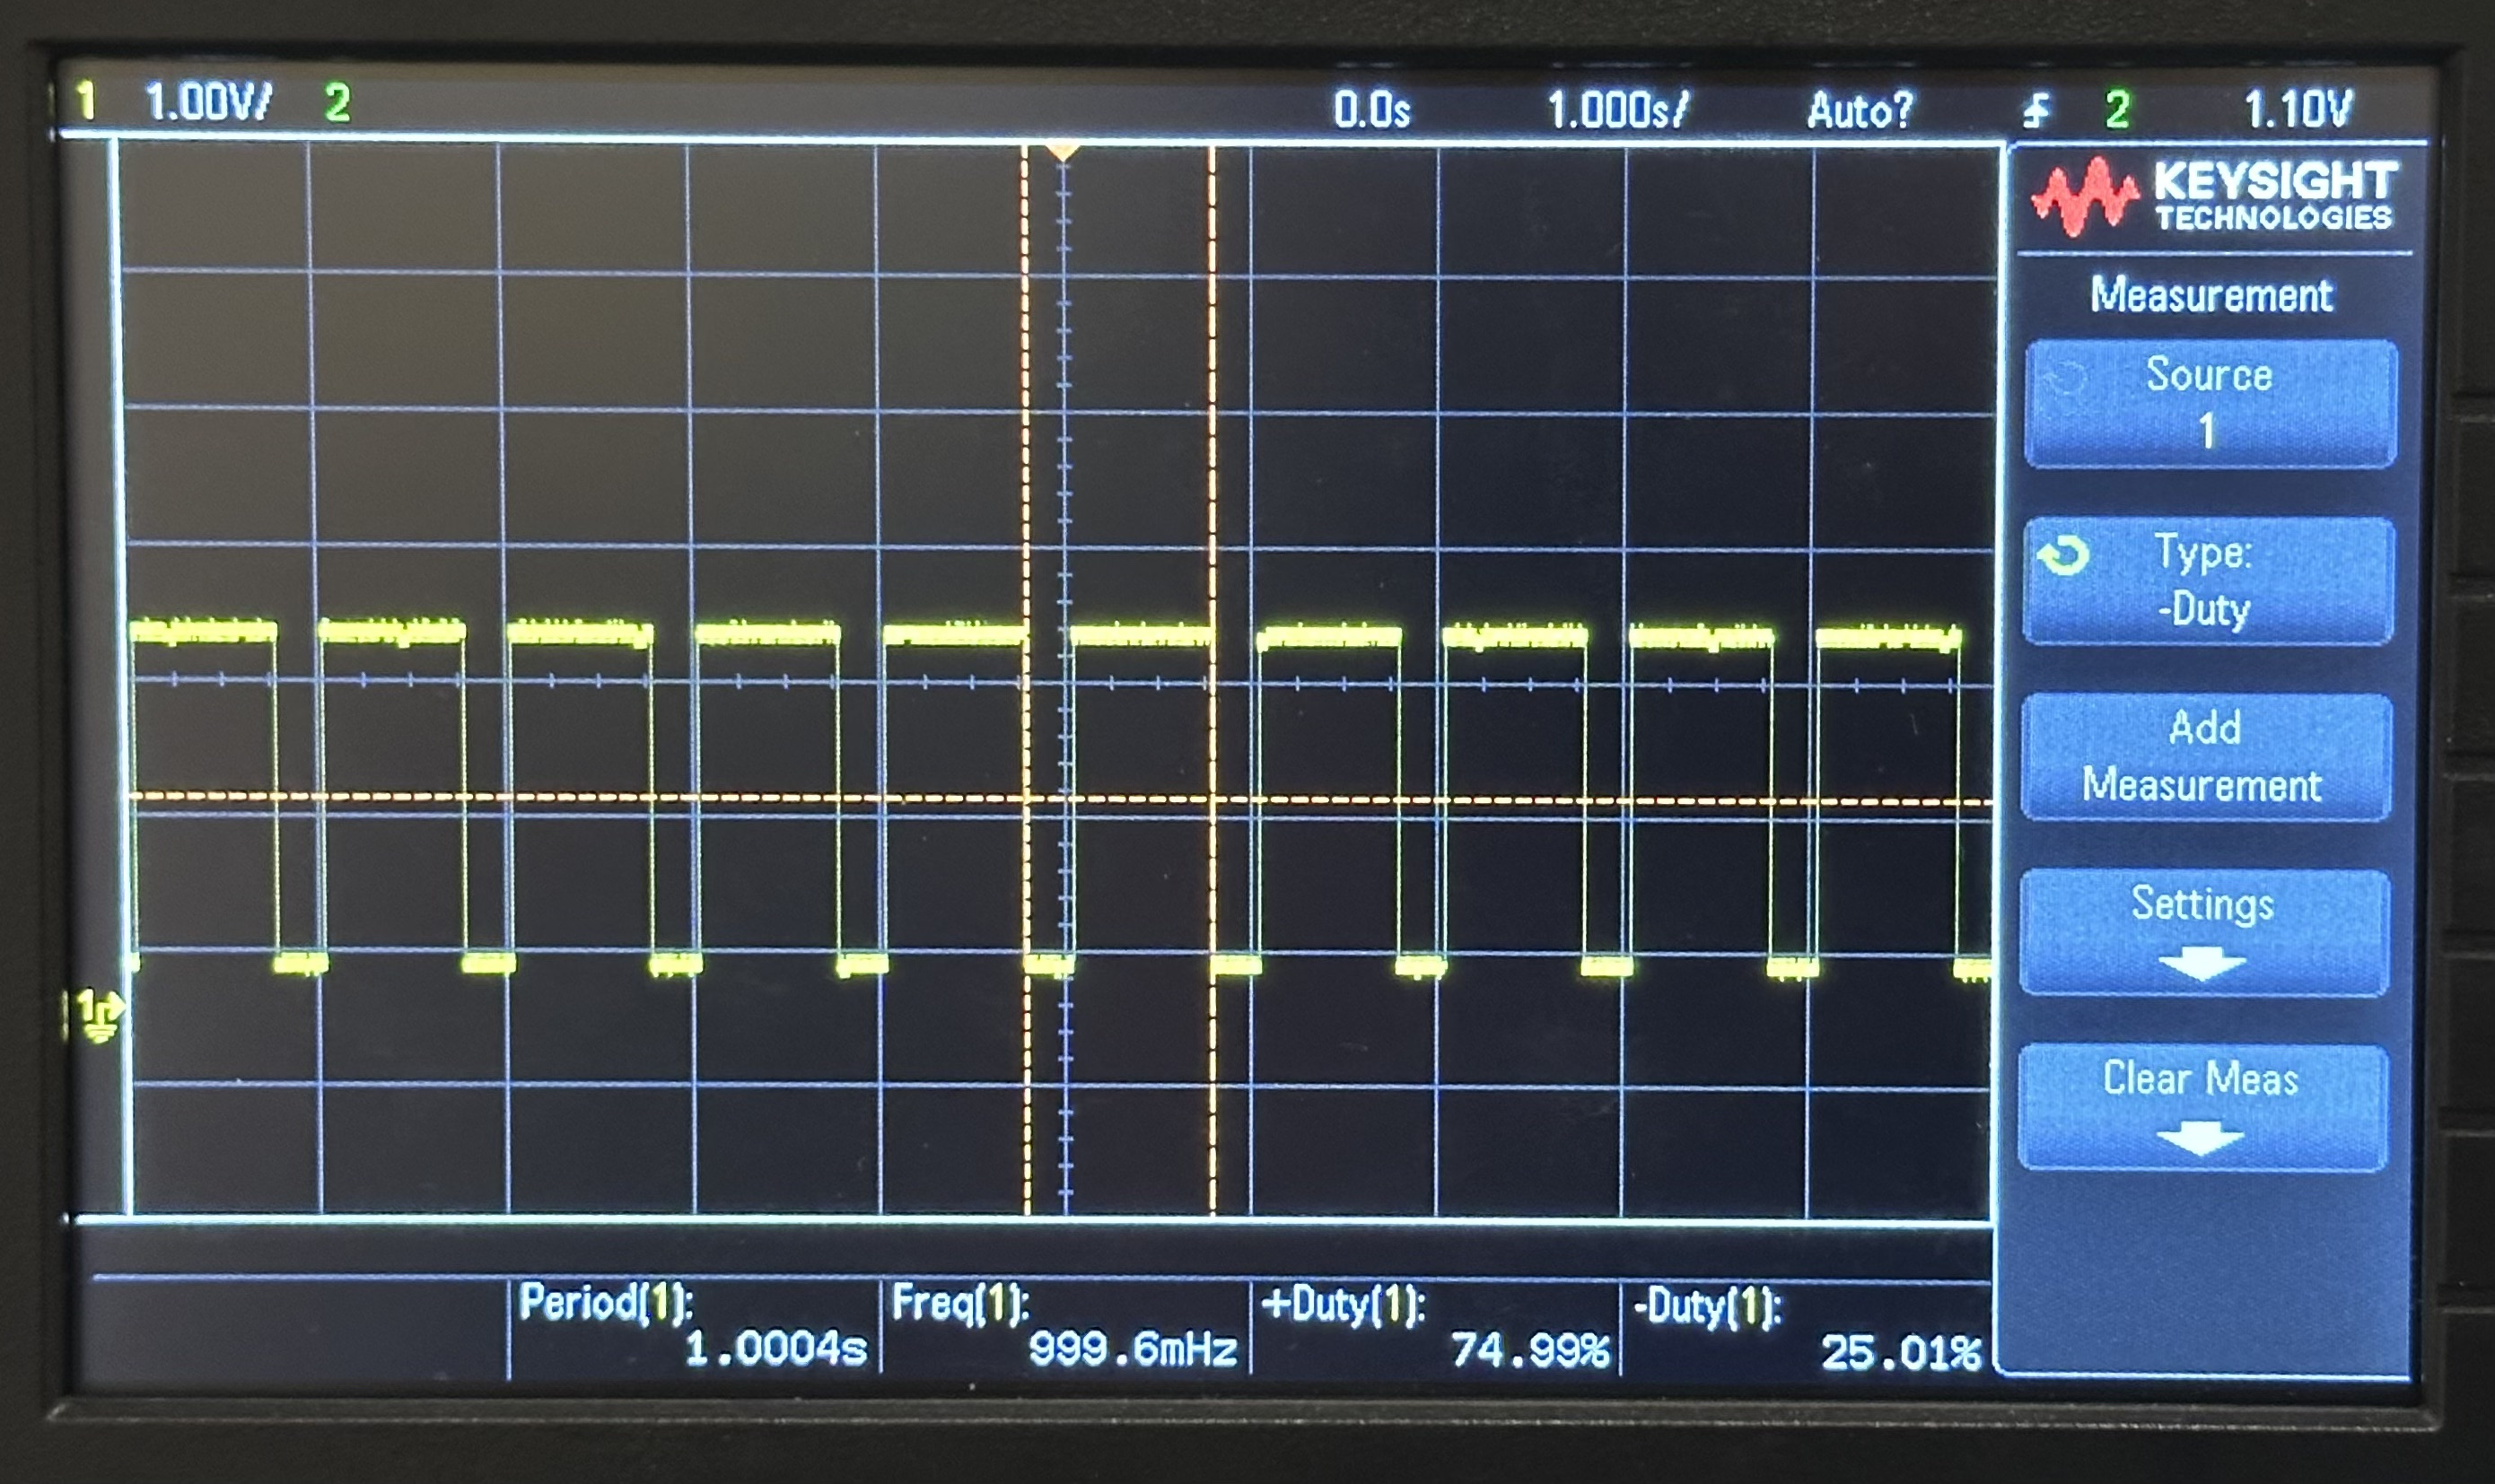

In [9]:
from IPython.display import Image, display

display(Image("HB.jpeg"))

In [16]:
hb_scope = pd.DataFrame({
    "Condition": ["Heartbeat thread (25% duty)"],
    "Measured Period (ms)": [1004.0],  
    "Nominal Period (ms)": [1000.0],
    "Measured Frequency (Hz)": [0.9996],  
    "Nominal Frequency (Hz)": [1.0],
    "Measured Duty Cycle": [0.2501],
    "Nominal Duty Cycle": [0.25],
    "Resolution (ms)": [0.1]        
})

hb_scope["Half Resolution (ms)"] = hb_scope["Resolution (ms)"] / 2

# Period CI
hb_scope["95% CI Period (ms)"] = hb_scope.apply(
    lambda row: (
        round(row["Measured Period (ms)"] - row["Half Resolution (ms)"], 3),
        round(row["Measured Period (ms)"] + row["Half Resolution (ms)"], 3)
    ),
    axis=1
)

# Frequency CI
hb_scope["95% CI Frequency (Hz)"] = hb_scope.apply(
    lambda row: (
        round(1000 / (row["Measured Period (ms)"] + row["Half Resolution (ms)"]), 4),
        round(1000 / (row["Measured Period (ms)"] - row["Half Resolution (ms)"]), 4)
    ),
    axis=1
)

# Duty cycle CI
hb_scope["95% CI Duty Cycle"] = hb_scope.apply(
    lambda row: (
        round((row["Measured Duty Cycle"] * row["Measured Period (ms)"] - row["Half Resolution (ms)"]) /
              (row["Measured Period (ms)"] + row["Half Resolution (ms)"]), 4),
        round((row["Measured Duty Cycle"] * row["Measured Period (ms)"] + row["Half Resolution (ms)"]) /
              (row["Measured Period (ms)"] - row["Half Resolution (ms)"]), 4)
    ),
    axis=1
)

hb_scope["Error vs Nominal Period (ms)"] = (
    hb_scope["Measured Period (ms)"] - hb_scope["Nominal Period (ms)"]
)

hb_scope["Error vs Nominal Frequency (Hz)"] = (
    hb_scope["Measured Frequency (Hz)"] - hb_scope["Nominal Frequency (Hz)"]
)

hb_scope["Error vs Nominal Duty Cycle"] = (
    hb_scope["Measured Duty Cycle"] - hb_scope["Nominal Duty Cycle"]
)

hb_scope

,Condition,Measured Period (ms),Nominal Period (ms),Measured Frequency (Hz),Nominal Frequency (Hz),Measured Duty Cycle,Nominal Duty Cycle,Resolution (ms),Half Resolution (ms),95% CI Period (ms),95% CI Frequency (Hz),95% CI Duty Cycle,Error vs Nominal Period (ms),Error vs Nominal Frequency (Hz),Error vs Nominal Duty Cycle
0,Heartbeat thread (25% duty),1004.0,1000.0,0.9996,1.0,0.2501,0.25,0.1,0.05,"(1003.95, 1004.05)","(0.996, 0.9961)","(0.25, 0.2502)",4.0,-0.0004,0.0001


## Discussion

The measured timing behavior of the refactored heartbeat LED thread closely matched the nominal specifications. Logged durations formed two distinct clusters corresponding to the ON and OFF intervals of the heartbeat signal. The shorter intervals were approximately 250 ms, while the longer intervals were approximately 750 ms, consistent with the intended 25% duty cycle design.

Combining the ON and OFF intervals yielded a total period near 1000 ms, corresponding to the expected 1 Hz heartbeat frequency. The calculated duty cycle, defined as the ratio of ON time to total period, was therefore approximately 0.25. All measured values were consistent with the nominal specifications within the resolution limits of the system timer.

As in the previous timer-based implementation, repeated measurements often produced identical values, resulting in a sample standard deviation of zero. This behavior reflects the finite resolution of the timestamp source rather than perfect physical timing precision. Because the timestamp measurements are quantized to the system tick period, the true timing uncertainty is bounded by ± half of one system tick.

Overall, the results confirm that the thread-based implementation of the heartbeat LED successfully reproduces the intended timing behavior. The measured ON time, OFF time, period, and duty cycle all align with the nominal design, demonstrating that replacing the kernel timer with a dedicated thread does not introduce any significant timing error. Any minor discrepancies from the nominal values can be attributed to tick quantization and timestamp conversion rather than instability in the thread execution.